# Greenhouse LoRaWAN Signal Mapping Pipeline
**Batenburg Beenen | Summer School Project**

Two-stage model: Log-distance path-loss baseline → Moran's I residual test → GPR residual kriging (if needed).

**Current status:** partial dataset (7 rows, 1 gateway position). Pipeline designed to extend to full dataset.

---
## Pipeline Overview
1. **Preprocessing** — load one CSV per row, assign grid labels per-row from paper timestamps, map to (x, y), merge into master dataframe
2. **EDA** — RSSI distribution, spatial scatter, RSSI vs distance
3. **Stage 1** — Fit log-distance path-loss model
4. **Residual analysis** — Moran's I spatial autocorrelation test
5. **Stage 2 (conditional)** — GPR on residuals if spatial structure detected
6. **Coverage heatmap** — predict RSSI across full greenhouse grid
7. **Gateway placement** — exhaustive evaluation of candidate positions

---
## 0. Imports & Config

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.distance import cdist
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from numpy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')

---
## 1. Config+Preprocessing


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ── GEOMETRY ──────────────────────────────────────────────────────────────
GRID_LENGTH_M   = 15.0
ROW_SPACING_M   = 1.6    # TODO: confirm with tape measure
Y_MAX           = 160.0  # total row length in meters —
GATEWAY_X       = 0.0    # TODO: measure this
GATEWAY_Y       = 0.0    # and this
COLLECTION_DATE = '2026-06-25'
TIMEZONE        = '+02:00'
PACKET_SIZE     = 34
RSSI_GOOD       = -90
RSSI_WEAK       = -110

ROW_GEOMETRY = {
    'R1354': {'x': -1.6},  
    'R1356': {'x':  1.6},
}

ROW_CONFIG = {
    1: {
        'csv': '25-6_1354.csv',
        'timestamps': {
            'R1354_G1':  ('10:33:58', '10:38:30'),
            'R1354_G2':  ('10:38:30', '10:39:50'),
            'R1354_G3':  ('10:39:50', '10:41:15'),
            'R1354_G4':  ('10:41:15', '10:42:25'),
            'R1354_G5':  ('10:42:25', '10:43:30'),
            'R1354_G6':  ('10:43:30', '10:44:30'),
            'R1354_G7':  ('10:44:30', '10:45:35'),
            'R1354_G8':  ('10:45:35', '10:46:40'),
            'R1354_G9':  ('10:46:40', '10:47:40'),
            'R1354_G10': ('10:47:40', '10:48:40'),
        }
    },
    2: {
        'csv': '25-6_1356.csv',
        'timestamps': {
            'R1356_G1':    ('11:06:58', '11:09:35'),
            'R1356_G2':    ('11:09:35', '11:10:50'),
            'R1356_G3':    ('11:10:50', '11:11:50'),  # check paper
            'R1356_G4':    ('11:11:50', '11:12:50'),
            'R1356_G5':    ('11:12:50', '11:13:50'),
            'R1356_G6':    ('11:13:50', '11:14:55'),
            'R1356_G7':    ('11:14:55', '11:15:55'),
            'R1356_G8':    ('11:15:55', '11:16:50'),  # check paper
            'R1356_G9':    ('11:16:50', '11:18:05'),
            'R1356_G10':   ('11:18:05', '11:19:10'),
            'R1356_G11':   ('11:19:10', '11:20:30'),
            'R1356_G7_B':  ('11:24:30', '11:27:00'),
        }
    },
    3: {
        'csv': '25-6_1185.csv',
        'timestamps': {
            'R1356_G-1':   ('11:36:25', '11:39:05'),
            'R1356_G-2':   ('11:39:05', '11:40:15'),
            'R1356_G-3':   ('11:40:15', '11:41:36'),
            'R1356_G-4':   ('11:41:36', '11:42:50'),
            'R1356_G-5':   ('11:42:50', '11:43:50'),
            'R1356_G-6':   ('11:43:50', '11:45:00'),
            'R1356_G-7':   ('11:45:00', '11:46:05'),
            'R1356_G-8':   ('11:46:05', '11:47:10'),
            'R1356_G-9':   ('11:47:10', '11:48:30'),
            'R1356_G-10':  ('11:48:30', '11:49:35'),
            'R1356_G-11':  ('11:49:35', '11:54:00'),
            'R1356_G-7_B': ('11:54:10', '11:57:00'),
        }
    },
    4: {
        'csv': '25-06_1187.csv',
        'timestamps': {
            'R1354_G-1':   ('12:07:45', '12:09:20'),
            'R1354_G-2':   ('12:09:20', '12:10:10'),
            'R1354_G-3':   ('12:10:10', '12:11:30'),
            'R1354_G-4':   ('12:11:30', '12:12:45'),
            'R1354_G-5':   ('12:12:45', '12:13:40'),
            'R1354_G-6':   ('12:13:40', '12:14:40'),
            'R1354_G-7':   ('12:14:40', '12:18:35'),
            'R1354_G-8':   ('12:18:35', '12:19:50'),
            'R1354_G-9':   ('12:19:50', '12:21:10'),
            'R1354_G-10':  ('12:21:10', '12:22:05'),
            'R1354_G-11':  ('12:22:05', '12:23:05'),
            'R1354_G-12':  ('12:23:05', '12:25:00'),
        }
    },
    # Add next week's rows here: 5, 6, 7 ...
}

print(f'{len(ROW_CONFIG)} rows configured.')

4 rows configured.


### 1b. merge data

In [16]:
# HELPERS

def parse_gateway_csv(filepath):
    raw     = pd.read_csv(filepath)
    uplinks = raw[raw['Type'] == 'UpUnc']
    df      = uplinks[uplinks['Size'] == PACKET_SIZE].copy()
    df['timestamp'] = pd.to_datetime(df['Time'], utc=True)
    df = df.sort_values('timestamp').reset_index(drop=True)
    df[['rssi', 'snr']] = df['RSSI/SNR'].str.strip().str.split('/', expand=True).astype(float)
    df['sf'] = df['Datarate'].str.extract(r'SF(\d+)').astype(int)
    return df[['timestamp', 'rssi', 'snr', 'sf']], len(uplinks) - len(df)


def assign_labels(df, timestamps):
    df = df.copy()
    df['grid_label'] = 'UNASSIGNED'
    skipped = []
    for label, (t_start, t_end) in timestamps.items():
        if t_end is None:
            skipped.append(label)
            continue
        ts_start = pd.Timestamp(f'{COLLECTION_DATE}T{t_start}{TIMEZONE}').tz_convert('UTC')
        ts_end   = pd.Timestamp(f'{COLLECTION_DATE}T{t_end}{TIMEZONE}').tz_convert('UTC')
        if ts_end <= ts_start:
            skipped.append(label)
            continue
        mask = (df['timestamp'] >= ts_start) & (df['timestamp'] < ts_end)
        df.loc[mask, 'grid_label'] = label
    return df, skipped


def label_to_coords(label):
    """'R1356_G-3' or 'R1356_G7_B' → (x, y) in meters."""
    label    = label.replace('_B', '')
    row_part, g_part = label.split('_G')
    g_index  = int(g_part)
    geom     = ROW_GEOMETRY.get(row_part)
    if geom is None:
        return np.nan, np.nan
    return geom['x'], g_index * GRID_LENGTH_M


# LOAD, LABEL, MERGE 
all_rows, report = [], []

for row_num, config in ROW_CONFIG.items():
    try:
        df, n_removed = parse_gateway_csv(config['csv'])
    except FileNotFoundError:
        print(f'  Row {row_num}: CSV not found — {config["csv"]}')
        continue

    df, skipped = assign_labels(df, config['timestamps'])
    coords = pd.DataFrame(
        [label_to_coords(lbl) if lbl != 'UNASSIGNED' else (np.nan, np.nan)
         for lbl in df['grid_label']],
        columns=['sensor_x', 'sensor_y']
    )
    df = pd.concat([df.reset_index(drop=True), coords], axis=1)
    df['row_num'] = row_num
    all_rows.append(df)
    report.append({
        'row':           row_num,
        'csv':           config['csv'],
        'total_uplinks': len(df) + n_removed,
        'removed_size':  n_removed,
        'kept':          len(df),
        'labeled':       int((df['grid_label'] != 'UNASSIGNED').sum()),
        'unassigned':    int((df['grid_label'] == 'UNASSIGNED').sum()),
        'skipped':       skipped,
    })

master  = pd.concat(all_rows, ignore_index=True)
labeled = master[master['grid_label'] != 'UNASSIGNED'].dropna(subset=['sensor_x', 'sensor_y']).copy()

labeled['gateway_x']     = GATEWAY_X
labeled['gateway_y']     = GATEWAY_Y
labeled['distance']      = np.sqrt(
    (labeled['sensor_x'] - GATEWAY_X)**2 +
    (labeled['sensor_y'] - GATEWAY_Y)**2
)
labeled['row_crossings'] = np.floor(
    np.abs(labeled['sensor_x'] - GATEWAY_X) / ROW_SPACING_M
).astype(int)

# REMOVAL REPORT 
print('=== Packet Removal Report ===')
for r in report:
    pct = r['removed_size'] / r['total_uplinks'] * 100
    print(f"\nRow {r['row']}  ({r['csv']})")
    print(f"  Total uplinks     : {r['total_uplinks']}")
    print(f"  Removed (size≠34) : {r['removed_size']}  ({pct:.0f}%)")
    print(f"  Kept  (size=34)   : {r['kept']}")
    print(f"  Labeled           : {r['labeled']}")
    print(f"  Unassigned        : {r['unassigned']}")
    if r['skipped']:
        print(f"  ⚠ Skipped labels  : {r['skipped']}  ← fix timestamps")

print(f'\nTotal labeled packets : {len(labeled)}')
print(f'Grid cells covered   : {labeled["grid_label"].nunique()}')
print()
print('Packets per grid label:')
print(labeled.groupby(['row_num', 'grid_label']).size().to_string())

=== Packet Removal Report ===

Row 1  (25-6_1354.csv)
  Total uplinks     : 154
  Removed (size≠34) : 70  (45%)
  Kept  (size=34)   : 84
  Labeled           : 58
  Unassigned        : 26

Row 2  (25-6_1356.csv)
  Total uplinks     : 127
  Removed (size≠34) : 62  (49%)
  Kept  (size=34)   : 65
  Labeled           : 58
  Unassigned        : 7

Row 3  (25-6_1185.csv)
  Total uplinks     : 204
  Removed (size≠34) : 98  (48%)
  Kept  (size=34)   : 106
  Labeled           : 82
  Unassigned        : 24

Row 4  (25-06_1187.csv)
  Total uplinks     : 143
  Removed (size≠34) : 77  (54%)
  Kept  (size=34)   : 66
  Labeled           : 66
  Unassigned        : 0

Total labeled packets : 264
Grid cells covered   : 45

Packets per grid label:
row_num  grid_label 
1        R1354_G1        5
         R1354_G10       5
         R1354_G2        7
         R1354_G3        6
         R1354_G4        6
         R1354_G5        6
         R1354_G6        6
         R1354_G7        6
         R1354_G8        

### 1c. Sanity check (packets per row)


In [17]:
labeled['row_name'] = labeled['grid_label'].str.extract(r'(R\d+)')
labeled['g_index']  = labeled['grid_label'].str.replace('_B','').str.extract(r'_G(-?\d+)').astype(int)

summary = (
    labeled.groupby(['row_name', 'g_index'])['rssi']
    .agg(n='count', mean='mean', std='std', min='min', max='max')
    .round(2)
)

summary['flag'] = ''
summary.loc[summary['n'] < 2,     'flag'] += '⚠ low count  '
summary.loc[summary['std'] > 6,   'flag'] += '⚠ high variance'

print('Packets per grid cell (sorted by row and position):')
print(summary.to_string())

Packets per grid cell (sorted by row and position):
                   n    mean   std    min    max             flag
row_name g_index                                                 
R1354    -11       2 -106.00  0.00 -106.0 -106.0                 
         -10       1 -105.00   NaN -105.0 -105.0    ⚠ low count  
         -9        6  -98.33  1.03 -100.0  -97.0                 
         -8        3 -102.67  1.15 -104.0 -102.0                 
         -7       22  -95.05  2.17 -103.0  -92.0                 
         -6        5  -96.00  4.18 -101.0  -92.0                 
         -5        5  -91.20  1.79  -94.0  -89.0                 
         -4        4  -79.50  1.91  -81.0  -77.0                 
         -3        6  -72.17  2.64  -77.0  -69.0                 
         -2        6  -66.33  4.32  -75.0  -64.0                 
         -1        6  -49.50  1.76  -52.0  -47.0                 
          1        5  -42.80  5.17  -52.0  -40.0                 
          2        7  -5

---
## 2. Exploratory Data Analysis

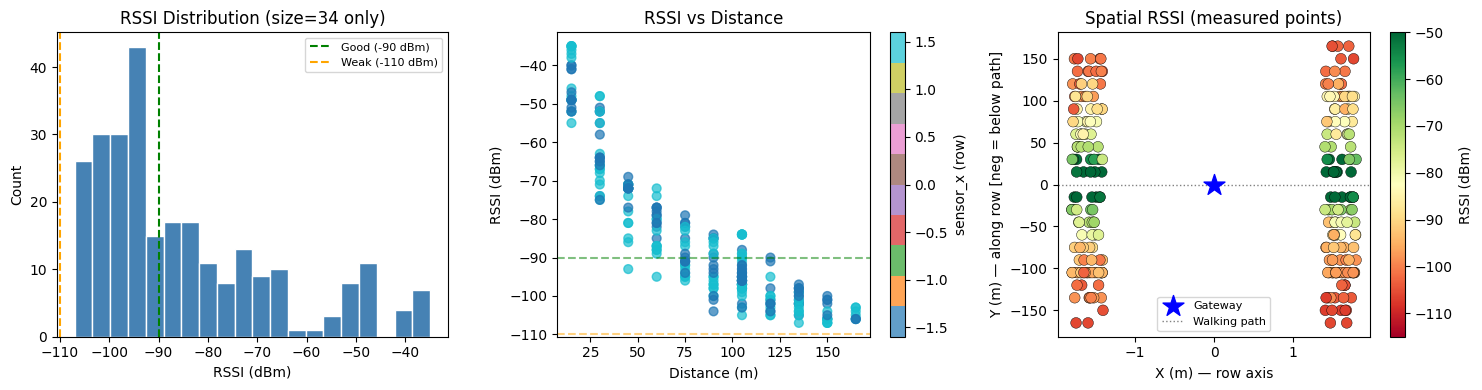

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. RSSI histogram
axes[0].hist(labeled['rssi'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(RSSI_GOOD, color='green',  linestyle='--', label=f'Good ({RSSI_GOOD} dBm)')
axes[0].axvline(RSSI_WEAK, color='orange', linestyle='--', label=f'Weak ({RSSI_WEAK} dBm)')
axes[0].set_xlabel('RSSI (dBm)')
axes[0].set_ylabel('Count')
axes[0].set_title('RSSI Distribution (size=34 only)')
axes[0].legend(fontsize=8)

# 2. RSSI vs distance
sc = axes[1].scatter(labeled['distance'], labeled['rssi'],
                     c=labeled['sensor_x'], cmap='tab10', alpha=0.7, s=40)
plt.colorbar(sc, ax=axes[1], label='sensor_x (row)')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('RSSI (dBm)')
axes[1].set_title('RSSI vs Distance')
axes[1].axhline(RSSI_GOOD, color='green',  linestyle='--', alpha=0.5)
axes[1].axhline(RSSI_WEAK, color='orange', linestyle='--', alpha=0.5)

# 3. Spatial scatter coloured by RSSI
np.random.seed(42)
jitter = np.random.uniform(-0.2, 0.2, len(labeled))
sc2 = axes[2].scatter(labeled['sensor_x'] + jitter, labeled['sensor_y'],
                      c=labeled['rssi'], cmap='RdYlGn', vmin=-115, vmax=-50,
                      s=60, edgecolors='k', linewidths=0.3)
axes[2].scatter(GATEWAY_X, GATEWAY_Y, marker='*', s=250, color='blue',
               zorder=5, label='Gateway')
axes[2].axhline(0, color='grey', linestyle=':', lw=1, label='Walking path')
plt.colorbar(sc2, ax=axes[2], label='RSSI (dBm)')
axes[2].set_xlabel('X (m) — row axis')
axes[2].set_ylabel('Y (m) — along row [neg = below path]')
axes[2].set_title('Spatial RSSI (measured points)')
axes[2].legend(fontsize=8)


plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Stage 1: Log-Distance Path-Loss Model

Fits: `RSSI = A_g − 10·n·log10(d) + β·row_crossings`
This formula is based on the widely used ITU model

With one gateway position, A_g is a single intercept. When we add data from multiple gateway positions, A_g becomes a per-gateway fixed effect, so we can later add a dummy-variable column per gateway and the same lstsq call handles it.

In [19]:
valid = labeled.dropna(subset=['distance', 'rssi']).copy()
valid = valid[valid['distance'] > 0]

log_d = np.log10(valid['distance'].values)
rssi  = valid['rssi'].values

"""Design matrix: [intercept, log10(d)] only.
row_crossings is omitted: with sensors at x=±1.6 m and the gateway at x=0,
 every packet crosses exactly 1 row: constant predictor, perfectly collinear
 with the intercept: beta is unidentifiable from the current data.
 Re-add the column once sensors at 0 or ≥2 crossings are collected."""

X_pl = np.column_stack([np.ones(len(valid)), log_d])
coeffs, _, _, _ = lstsq(X_pl, rssi, rcond=None)
A_g, n_log10 = coeffs
beta = 0.0  # placeholder (re-estimate with multi-crossing data)

valid['pl_pred']     = X_pl @ coeffs
valid['pl_residual'] = valid['rssi'] - valid['pl_pred']
rmse = np.sqrt(mean_squared_error(valid['rssi'], valid['pl_pred']))

print('=== Path-Loss Model Results ===')
print(f'  A_g (intercept)     : {A_g:.2f} dBm')
print(f'  n   (path-loss exp) : {-n_log10/10:.3f}  [free-space baseline = 2; indoor typical = 2.5–4]')
print(f'  β   (row penalty)   : not estimable — all sensors cross exactly 1 row')
print(f'  RMSE                : {rmse:.2f} dBm')


=== Path-Loss Model Results ===
  A_g (intercept)     : 24.74 dBm
  n   (path-loss exp) : 5.957  [free-space baseline = 2; indoor typical = 2.5–4]
  β   (row penalty)   : not estimable — all sensors cross exactly 1 row
  RMSE                : 5.47 dBm


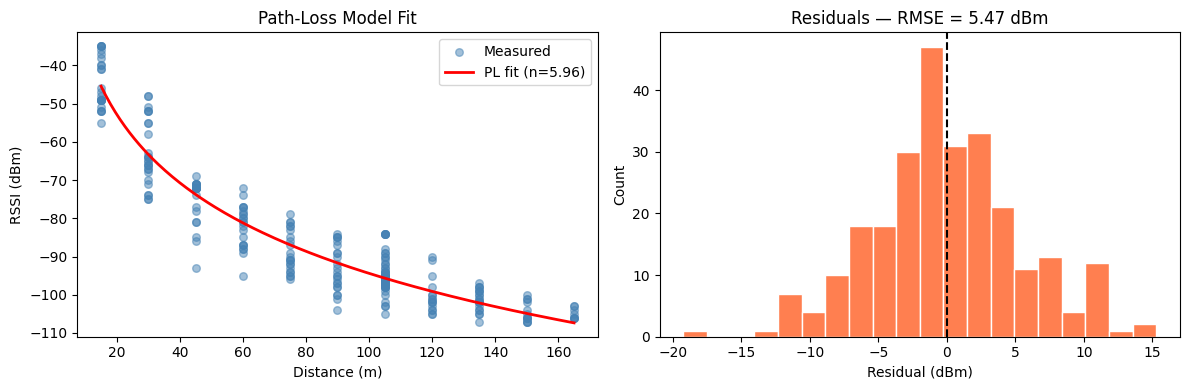

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

d_range = np.linspace(valid['distance'].min(), valid['distance'].max(), 200)
pl_line = A_g + n_log10 * np.log10(d_range)   # beta=0 (not yet estimable from current data)

axes[0].scatter(valid['distance'], valid['rssi'], alpha=0.5, s=30,
               label='Measured', color='steelblue')
axes[0].plot(d_range, pl_line, 'r-', lw=2,
            label=f'PL fit (n={-n_log10/10:.2f})')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('RSSI (dBm)')
axes[0].set_title('Path-Loss Model Fit')
axes[0].legend()

axes[1].hist(valid['pl_residual'], bins=20, color='coral', edgecolor='white')
axes[1].axvline(0, color='k', linestyle='--')
axes[1].set_xlabel('Residual (dBm)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residuals — RMSE = {rmse:.2f} dBm')

plt.tight_layout()
plt.savefig('pathloss_fit.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Residual Analysis: Moran's I Spatial Autocorrelation

- **p < 0.05 and I > 0** → spatial clustering in residuals → proceed to GPR (Stage 2)
- **p ≥ 0.05** → residuals effectively random → path-loss model is sufficient

Running Moran's I on 45 grid cell means (not 264 individual packets)
=== Moran's I Test ===
  Moran's I : 0.4776
  p-value   : 0.0010  (permutation, 999 iterations)

Significant positive spatial autocorrelation: we should proceed to GPR residual model.


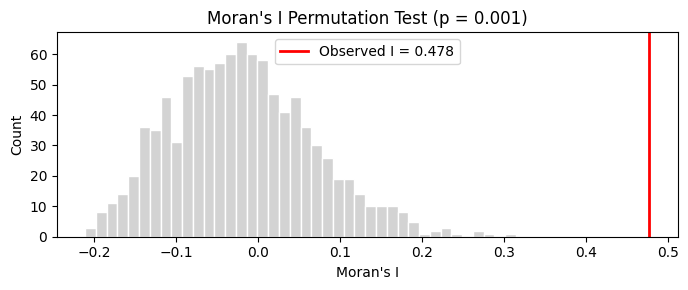

In [22]:
def morans_i(coords, values, k_neighbors=5, n_permutations=999):
    """Moran's I with k-NN spatial weights and permutation p-value."""
    n = len(values)
    z = values - values.mean()
    dist_mat = cdist(coords, coords)
    np.fill_diagonal(dist_mat, np.inf)
    W = np.zeros((n, n))
    for i in range(n):
        neighbors = np.argsort(dist_mat[i])[:k_neighbors]
        W[i, neighbors] = 1
    W = (W + W.T) / 2
    W_sum = W.sum()
    I_obs = (n / W_sum) * (z @ W @ z) / (z @ z)
    I_perm = np.zeros(n_permutations)
    for _i in range(n_permutations):
        z_p = np.random.permutation(z)
        I_perm[_i] = (n / W_sum) * (z_p @ W @ z_p) / (z @ z)
    p_value = (np.sum(I_perm >= I_obs) + 1) / (n_permutations + 1)
    return I_obs, p_value, I_perm

# Aggregate to one mean residual per grid cell before testing.
# We used repeated measurements (multiple packets from the same loc), not independent spatial units (if we just use them they would inflate the effective N.)
cell_means = (
    valid.groupby('grid_label')
    .agg(
        mean_residual=('pl_residual', 'mean'),
        sensor_x=('sensor_x', 'first'),
        sensor_y=('sensor_y', 'first'),
        n=('pl_residual', 'count')
    )
    .reset_index()
)

print(f"Running Moran's I on {len(cell_means)} grid cell means (not {len(valid)} individual packets)")

np.random.seed(42)
coords_arr    = cell_means[['sensor_x', 'sensor_y']].values
residuals_arr = cell_means['mean_residual'].values
k = min(5, len(cell_means) - 1)  #if p is borderline lower this or change to a distance-band weight matrix
I, p_val, I_perm = morans_i(coords_arr, residuals_arr, k_neighbors=k)

print("=== Moran's I Test ===")
print(f"  Moran's I : {I:.4f}")
print(f"  p-value   : {p_val:.4f}  (permutation, 999 iterations)")
print()

if p_val < 0.05 and I > 0:
    print('Significant positive spatial autocorrelation: we should proceed to GPR residual model.')
    USE_GPR = True
else:
    print('No significant spatial autocorrelation: the path-loss model is sufficient.')
    USE_GPR = False

plt.figure(figsize=(7, 3))
plt.hist(I_perm, bins=40, color='lightgrey', edgecolor='white')
plt.axvline(I, color='red', lw=2, label=f'Observed I = {I:.3f}')
plt.xlabel("Moran's I")
plt.ylabel('Count')
plt.title(f"Moran's I Permutation Test (p = {p_val:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig('morans_i.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Stage 2 (Conditional): GPR on Residuals

In [24]:
# GPR INPUT PREPARATION
# pl_residual lives in 'valid', merge back into labeled by packets
labeled = labeled.merge(
    valid[['timestamp', 'pl_pred', 'pl_residual']],
    on='timestamp',
    how='left'
)

print(f"Packets with residual: {labeled['pl_residual'].notna().sum()} / {len(labeled)}")
# Use all labeled packets for GPR
X_gpr = labeled[['sensor_x', 'sensor_y']].values.copy()
y_gpr = labeled['pl_residual'].values

# Add tiny jitter to duplicate locations so K is invertible
# (packets at the same grid cell get slightly different coords, maybe we will use GPR on means we have to think about this!!!!!!!)
np.random.seed(42)
X_gpr += np.random.normal(0, 0.01, X_gpr.shape)

print(f'GPR training set: {X_gpr.shape[0]} packets')
print(f'Residual range  : {y_gpr.min():.2f} to {y_gpr.max():.2f} dBm')
print(f'Residual mean   : {y_gpr.mean():.2f} dBm')

Packets with residual: 264 / 264
GPR training set: 264 packets
Residual range  : -19.24 to 15.29 dBm
Residual mean   : -0.00 dBm


In [25]:
# Scale coordinates to zero mean, unit variance
# GPR is sensitive to the scale of inputs, without this the  hyperparameter optimisation might fail/converge poorly
scaler = StandardScaler()
X_gpr_scaled = scaler.fit_transform(X_gpr)

print('Coordinate scaling:')
print(f'  X mean: {scaler.mean_[0]:.2f} m  std: {scaler.scale_[0]:.2f} m')
print(f'  Y mean: {scaler.mean_[1]:.2f} m  std: {scaler.scale_[1]:.2f} m')

""" KERNEL DEFINITION 
Following the paper's notation:
K = ConstantKernel (σ_f²) × Matérn(l) + WhiteKernel (σ_n²)
ConstantKernel : overall signal variance σ_f², scales the amplitude
                  of residual predictions (paper's vertical scale σ_f)
Matérn ν=1.5  : spatial correlation structure, how fast similarity
                  decays with distance (paper's horizontal scale l)
                  ν=1.5 assumes once-differentiable functions, appropriate
                 for physical fields with possible sharp transitions
WhiteKernel    : observation noise σ_n², absorbs within-cell RSSI
                  variance (the packet-to-packet fluctuation at same location)"""

kernel = (
    ConstantKernel(1.0, (0.1, 10.0)) *
    Matern(length_scale=1.0, length_scale_bounds=(0.01, 10.0), nu=1.5) +
    WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 10.0))
)

print(f'\nKernel before fitting:\n  {kernel}')

Coordinate scaling:
  X mean: 0.10 m  std: 1.60 m
  Y mean: -11.08 m  std: 92.76 m

Kernel before fitting:
  1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1)


In [26]:
# FIT GPR
# n_restarts_optimizer: fits the kernel hyperparameters from 5 different
# random starting points and keeps the best. This reduces risk of landing in
# a local optimum of the log marginal likelihood (paper p.6)
# normalize_y: subtracts the mean of y before fitting — good practice
# even though our residual mean is already ~0

gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=5,
    normalize_y=True,
    random_state=42
)

gpr.fit(X_gpr_scaled, y_gpr)

print('=== GPR Fitted Kernel ===')
print(f'  {gpr.kernel_}')
print()

# Extract fitted hyperparameters
k_amplitude = gpr.kernel_.k1.k1.constant_value**0.5   # σ_f
k_length    = gpr.kernel_.k1.k2.length_scale           # l (in scaled units)
k_noise     = gpr.kernel_.k2.noise_level**0.5          # σ_n

# Convert length scale back to meters for interpretability
l_meters_x = k_length * scaler.scale_[0]
l_meters_y = k_length * scaler.scale_[1]

print(f'  σ_f (amplitude)       : {k_amplitude:.3f} dBm')
print(f'  l   (length scale)    : {k_length:.3f} (scaled units)')
print(f'                          ≈ {l_meters_x:.1f} m along X  |  {l_meters_y:.1f} m along Y')
print(f'  σ_n (noise std dev)   : {k_noise:.3f} dBm')
print()
print('Interpretation:')
print(f'  Spatial correlation drops to near zero beyond ~{l_meters_y:.0f} m along the row')
print(f'  and ~{l_meters_x:.1f} m across rows.')
print(f'  Packet-to-packet noise std: {k_noise:.2f} dBm')

=== GPR Fitted Kernel ===
  0.68**2 * Matern(length_scale=0.277, nu=1.5) + WhiteKernel(noise_level=0.478)

  σ_f (amplitude)       : 0.680 dBm
  l   (length scale)    : 0.277 (scaled units)
                          ≈ 0.4 m along X  |  25.7 m along Y
  σ_n (noise std dev)   : 0.691 dBm

Interpretation:
  Spatial correlation drops to near zero beyond ~26 m along the row
  and ~0.4 m across rows.
  Packet-to-packet noise std: 0.69 dBm


In [27]:
# Check train set performance
y_pred_train, y_std_train = gpr.predict(X_gpr_scaled, return_std=True)
rmse_gpr = np.sqrt(mean_squared_error(y_gpr, y_pred_train))

print(f'GPR train RMSE on residuals : {rmse_gpr:.3f} dBm')
print(f'Path-loss RMSE              : {rmse:.2f} dBm')
print(f'Combined RMSE               : {np.sqrt(mean_squared_error(labeled.dropna(subset=["pl_residual"])["rssi"], labeled.dropna(subset=["pl_residual"])["pl_pred"] + y_pred_train)):.2f} dBm')

# Check if GPR is actually adding value
print()
print(f'Residual std before GPR : {y_gpr.std():.3f} dBm')
print(f'Residual std after GPR  : {(y_gpr - y_pred_train).std():.3f} dBm')

GPR train RMSE on residuals : 3.579 dBm
Path-loss RMSE              : 5.47 dBm
Combined RMSE               : 3.58 dBm

Residual std before GPR : 5.471 dBm
Residual std after GPR  : 3.579 dBm




The along-row spatial correlation is well-estimated at ~26m. The cross-row structure cannot be reliably estimated from the current dataset due to insufficient x-axis coverage, and is expected to improve substantially once the full row sweep is completed next week.

In [28]:
# DEFINE PREDICTION GRID
# Query points cover the full greenhouse floor at 0.5m resolution
# Y range: negative (opposite side on the path from gateway) to positive (same side as gateway)
# X range: covers all rows collected so far

x_coords = sorted(labeled['sensor_x'].unique())
X_MIN, X_MAX = min(x_coords) - ROW_SPACING_M, max(x_coords) + ROW_SPACING_M

Y_MIN = labeled['sensor_y'].min() - GRID_LENGTH_M
Y_MAX_PRED = labeled['sensor_y'].max() + GRID_LENGTH_M

grid_res = 1.0   # meters — increase to 0.5 for finer heatmap (slower)
x_grid = np.arange(X_MIN, X_MAX + grid_res, grid_res)
y_grid = np.arange(Y_MIN, Y_MAX_PRED + grid_res, grid_res)
XX, YY = np.meshgrid(x_grid, y_grid)
query_pts = np.column_stack([XX.ravel(), YY.ravel()])

print(f'Prediction grid: {len(x_grid)} × {len(y_grid)} = {len(query_pts)} points')
print(f'X range: {X_MIN:.1f} to {X_MAX:.1f} m')
print(f'Y range: {Y_MIN:.1f} to {Y_MAX_PRED:.1f} m')

Prediction grid: 8 × 361 = 2888 points
X range: -3.2 to 3.2 m
Y range: -180.0 to 180.0 m


In [29]:
# PREDICT PATH-LOSS BASELINE AT EVERY GRID POINT
dx   = query_pts[:, 0] - GATEWAY_X
dy   = query_pts[:, 1] - GATEWAY_Y
dist = np.maximum(np.sqrt(dx**2 + dy**2), 0.1)

pl_pred_grid = A_g + n_log10 * np.log10(dist)   # beta=0 for now

# PREDICT GPR RESIDUAL AT EVERY GRID POINT 
query_scaled = scaler.transform(query_pts)
gpr_resid_grid, gpr_std_grid = gpr.predict(query_scaled, return_std=True)

# COMBINE: full RSSI prediction = path-loss + GPR residual
rssi_pred_grid = pl_pred_grid + gpr_resid_grid

RSSI_grid = rssi_pred_grid.reshape(XX.shape)
STD_grid  = gpr_std_grid.reshape(XX.shape)

# Coverage summary
pct_good = np.mean(rssi_pred_grid >= RSSI_GOOD) * 100
pct_weak = np.mean((rssi_pred_grid >= RSSI_WEAK) & (rssi_pred_grid < RSSI_GOOD)) * 100
pct_dead = np.mean(rssi_pred_grid < RSSI_WEAK) * 100

print(f'\nCoverage for gateway at ({GATEWAY_X}, {GATEWAY_Y}):')
print(f'  Good  (> {RSSI_GOOD} dBm) : {pct_good:.1f}%')
print(f'  Weak  (> {RSSI_WEAK} dBm) : {pct_weak:.1f}%')
print(f'  Dead  (< {RSSI_WEAK} dBm) : {pct_dead:.1f}%')


Coverage for gateway at (0.0, 0.0):
  Good  (> -90 dBm) : 46.6%
  Weak  (> -110 dBm) : 53.4%
  Dead  (< -110 dBm) : 0.0%


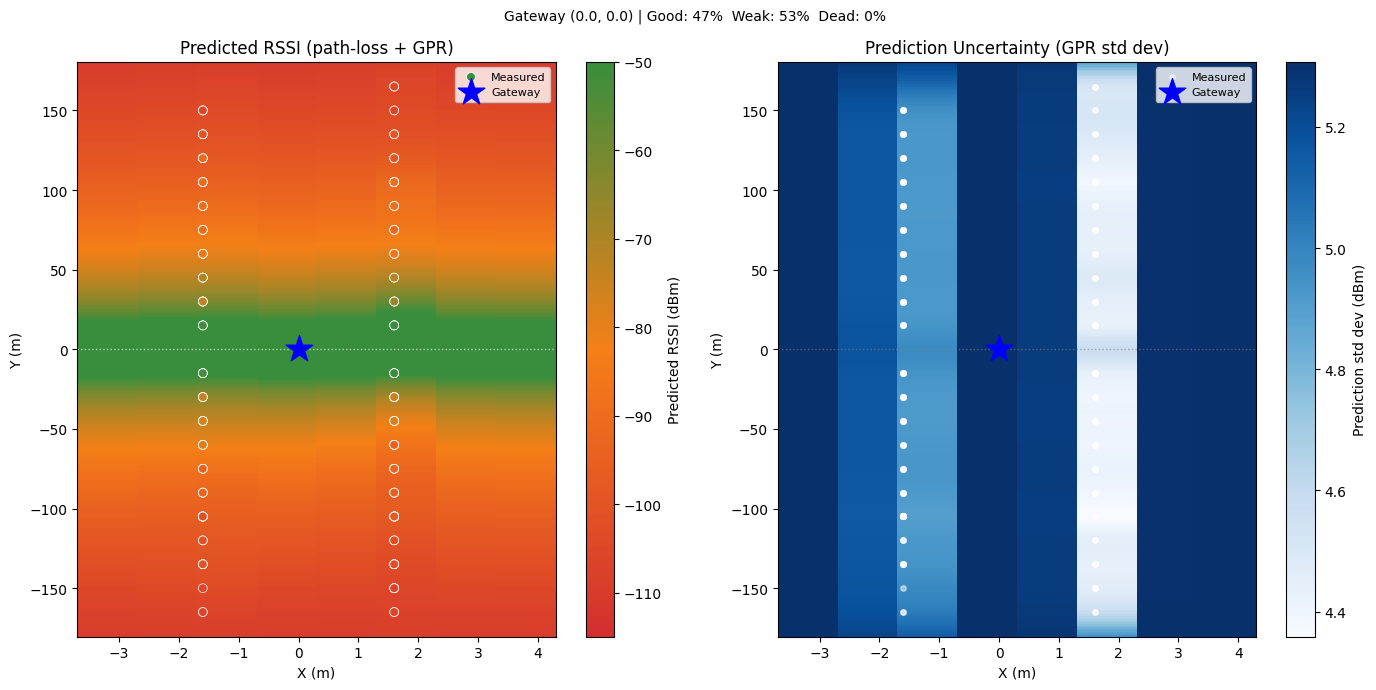

Saved: coverage_heatmap.png


In [30]:
# HEATMAP
cmap_rssi = LinearSegmentedColormap.from_list('rssi', ['#d32f2f', '#f57f17', '#388e3c'])
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: predicted RSSI
im1 = axes[0].pcolormesh(x_grid, y_grid, RSSI_grid,
                          cmap=cmap_rssi, vmin=-115, vmax=-50, shading='auto')
plt.colorbar(im1, ax=axes[0], label='Predicted RSSI (dBm)')

# Overlay measured points
axes[0].scatter(labeled['sensor_x'], labeled['sensor_y'],
               c=labeled['rssi'], cmap=cmap_rssi, vmin=-115, vmax=-50,
               s=40, edgecolors='white', linewidths=0.5, zorder=5,
               label='Measured')
axes[0].scatter(GATEWAY_X, GATEWAY_Y, marker='*', s=400,
               color='blue', zorder=10, label='Gateway')
axes[0].axhline(0, color='white', linestyle=':', lw=1, alpha=0.6)
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')
axes[0].set_title('Predicted RSSI (path-loss + GPR)')
axes[0].legend(fontsize=8)

# Right: prediction uncertainty
im2 = axes[1].pcolormesh(x_grid, y_grid, STD_grid,
                          cmap='Blues', shading='auto')
plt.colorbar(im2, ax=axes[1], label='Prediction std dev (dBm)')
axes[1].scatter(labeled['sensor_x'], labeled['sensor_y'],
               c='white', s=15, zorder=5, alpha=0.5, label='Measured')
axes[1].scatter(GATEWAY_X, GATEWAY_Y, marker='*', s=400,
               color='blue', zorder=10, label='Gateway')
axes[1].axhline(0, color='grey', linestyle=':', lw=1, alpha=0.6)
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Y (m)')
axes[1].set_title('Prediction Uncertainty (GPR std dev)')
axes[1].legend(fontsize=8)

plt.suptitle(
    f'Gateway ({GATEWAY_X}, {GATEWAY_Y}) | '
    f'Good: {pct_good:.0f}%  Weak: {pct_weak:.0f}%  Dead: {pct_dead:.0f}%',
    fontsize=10
)
plt.tight_layout()
plt.savefig('coverage_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: coverage_heatmap.png')